# 01 — Exact zero sound: a quickstart

**What this shows.** The engine's core method on its simplest problem: the zero-sound velocity of a
Fermi liquid, obtained as an *exact algebraic number* rather than a floating-point approximation.
Floats appear only at the end, to check the exact answer against an independent 60-digit reference.

**Time:** under a minute. **Prerequisites:** the Landau dispersion relation for zero sound at the level
of Baym & Pethick, *Landau Fermi-Liquid Theory*, ch. 1.

Steps:
1. the Landau kernel as an exact rational series;
2. its diagonal Padé approximant;
3. the dispersion relation as a polynomial and its exact root;
4. convergence against a 60-digit reference;
5. the engine refusing a float;
6. where the method stops: weak coupling.

In [1]:
# Locate the repository root, so this notebook runs from any working directory inside it.
import sys, contextlib, io
from pathlib import Path
ROOT = Path.cwd().resolve()
while not (ROOT / "agora_swarm").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

def quiet():
    """The engine narrates each step on stdout; hide that inside loops."""
    return contextlib.redirect_stdout(io.StringIO())

import numpy as np, sympy as sp, mpmath as mp
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 90, "font.size": 9, "axes.spines.top": False, "axes.spines.right": False})
print("repository:", ROOT.name)

repository: SocrateAI-Scientific-Agora-Physique-Cinetique


## 1. The kernel as a rational series

With only the Landau parameter $F_0^s$, undamped zero sound travels at $c_0 = s\,v_F$, where $s>1$ solves
$$\chi(s) = \frac{s}{2}\ln\frac{s+1}{s-1} - 1 = \frac{1}{F_0^s}.$$
In the variable $u = 1/s^2$ the kernel is $\chi = \sum_{k\ge1} u^k/(2k+1)$: every coefficient is rational.

In [2]:
from agora_swarm.agents.linear_response import LinearResponseStage, ScientificHonestyException
from agora_swarm.agents.kinetic import KineticStage
linear, kinetic = LinearResponseStage(), KineticStage()

with quiet():
    a = linear.landau_zero_sound_kernel(order=10)
print("coefficients a_k:", a)

# the coefficients are not typed in: check them against the series of the closed form
u, s = sp.symbols("u s", positive=True)
closed = (s / 2) * sp.log((s + 1) / (s - 1)) - 1
series = sp.series(closed.subs(s, 1 / sp.sqrt(u)), u, 0, 11).removeO()
assert all(sp.simplify(series.coeff(u, k) - a[k]) == 0 for k in range(1, 11))
print("matches the series of (s/2) ln((s+1)/(s-1)) - 1 through u^10")

coefficients a_k: [0, 1/3, 1/5, 1/7, 1/9, 1/11, 1/13, 1/15, 1/17, 1/19, 1/21]


matches the series of (s/2) ln((s+1)/(s-1)) - 1 through u^10


## 2. The diagonal Padé approximant

A power series converges only up to its nearest singularity. Here that is the branch point at $u=1$, which is exactly where
zero sound meets the particle-hole continuum. A rational function $P_M/Q_M$ that matches the series through
$u^{2M}$ usually does much better. It is computed here by exact linear algebra over $\mathbb{Q}$.

In [3]:
with quiet():
    P, Q, uu = kinetic.pade_diagonal(a, 2)
print("P_2(u) =", P)
print("Q_2(u) =", Q)
# the defining property: A Q - P = O(u^5)
A = sum(a[n] * uu**n for n in range(5))
print("A Q - P through u^4:", sp.series(sp.expand(A * Q - P), uu, 0, 5).removeO())

P_2(u) = -23*u**2/135 + u/3
Q_2(u) = 5*u**2/21 - 10*u/9 + 1
A Q - P through u^4: 0


## 3. The exact root

$\chi = 1/F_0^s$ becomes the polynomial $Q_M(u) - F_0^s P_M(u) = 0$. For a strong coupling like $F_0^s = 93/10$ at $M=1$ the
root is small enough to check by hand: $P_1 = u/3$ and $Q_1 = 1 - 3u/5$, so $u = 15/(9+5F_0^s) = 10/37$.

In [4]:
F0 = sp.Rational(93, 10)
roots = {}
for M in (1, 2, 3, 4):
    with quiet():
        r = kinetic.solve_zero_sound_root(a, F0, M=M)
    roots[M] = r
    print(f"M = {M}:  u = {r['u_exact']}")
print("\nM = 1 gives s =", roots[1]["s_exact"], "=", sp.N(sp.sympify(roots[1]["s_exact"]), 12))

M = 1:  u = 10/37


M = 2:  u = 13265/11482 - 5*sqrt(4144945)/11482


M = 3:  u = CRootOf(102367*x**3 - 582876*x**2 + 708015*x - 150150, 0)


M = 4:  u = CRootOf(2898821*x**4 - 30185595*x**3 + 78963885*x**2 - 66591525*x + 12762750, 0)

M = 1 gives s = sqrt(370)/10 = 1.92353840617


## 4. Convergence against an independent reference

The reference is a 60-digit root of the *transcendental* equation from `mpmath`. It shares nothing with the Padé
construction, and it is the only place floating point enters.

M = 1:  s = 1.92353840616713   relative error 2.9e-03
M = 2:  s = 1.92908272464643   relative error 1.8e-05


M = 3:  s = 1.92911708628447   relative error 1.1e-07
M = 4:  s = 1.92911729875238   relative error 6.8e-10


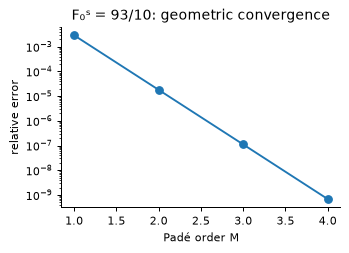

In [5]:
mp.mp.dps = 60
ref = mp.findroot(lambda s: s / 2 * mp.log((s + 1) / (s - 1)) - 1 - 1 / mp.mpf("9.3"), 1.9)
errs = []
for M, r in roots.items():
    sM = mp.mpf(str(sp.N(sp.sympify(r["s_exact"]), 50)))
    errs.append(float(abs(sM / ref - 1)))
    print(f"M = {M}:  s = {mp.nstr(sM, 15)}   relative error {errs[-1]:.1e}")
plt.figure(figsize=(4, 2.6))
plt.semilogy(list(roots), errs, "o-")
plt.xlabel("Padé order M"); plt.ylabel("relative error"); plt.title("F₀ˢ = 93/10: geometric convergence")
plt.show()

## 5. Floats are refused, not converted

The rule *Zéro Simulation Flottante* is enforced in code. A coupling passed as `9.3` is refused, because it has already
been rounded before the engine sees it.

In [6]:
try:
    kinetic.solve_zero_sound_root(a, 9.3, M=2)
except ScientificHonestyException as e:
    print("refused:", e)

🌌 [kinetic stage] Solving exact zero-sound dispersion, F_0^s = 9.3, [2/2] Pade...
refused: F_0^s was supplied as a float; pass sympy.Rational to keep the derivation exact.


## 6. Where the method stops

For weak coupling the mode hugs the continuum edge, $s-1 \approx 2e^{-2-2/F_0^s}$. That is exponentially small, and it
sits right at the branch point the Padé construction cannot reach. The engine reports **no root** instead of inventing one.
The repository proves the two-sided bound $2e^{-(2+2/F)} \le s-1 \le F$ in Lean 4 (`ZeroSoundBracket.lean`).

In [7]:
with quiet():
    weak = kinetic.solve_zero_sound_root(a, sp.Rational(1, 10), M=4)
print("F0s = 1/10, M = 4: root found?", weak["root_found"])
for F in ("0.1", "0.2", "0.5"):
    F = mp.mpf(F)
    # solve for y = ln(s - 1): the root is exponentially close to s = 1
    y = mp.findroot(lambda y: (1 + mp.exp(y)) / 2 * mp.log((2 + mp.exp(y)) / mp.exp(y)) - 1 - 1 / F, (-200, 5), solver="anderson")
    s0 = 1 + mp.exp(y)
    lo, hi = 2 * mp.exp(-(2 + 2 / F)), F
    print(f"F = {mp.nstr(F, 2)}:  s - 1 = {mp.nstr(s0 - 1, 6)}   bracket [{mp.nstr(lo, 6)}, {mp.nstr(hi, 3)}]   inside: {lo <= s0 - 1 <= hi}")

F0s = 1/10, M = 4: root found? False
F = 0.1:  s - 1 = 5.57894e-10   bracket [5.57894e-10, 0.1]   inside: True
F = 0.2:  s - 1 = 1.22903e-5   bracket [1.22884e-5, 0.2]   inside: True
F = 0.5:  s - 1 = 0.0051246   bracket [0.0049575, 0.5]   inside: True


**Next:** notebook 02 runs the same machinery on *measured* ³He Landau parameters. There this one-parameter model turns out to be wrong.